In [1]:
1+1

2

In [1]:
##Build a basic chatbot
#Adding libraries
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [3]:
graph_builder = StateGraph(State)
graph_builder

In [4]:
#Build Graph

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [5]:
from langchain_groq import ChatGroq

llm = ChatGroq(model_name="qwen/qwen3-32b")



In [6]:
#Node functionality

def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [7]:
graph_builder.add_node("llmchatbot1", chatbot)

graph_builder.add_edge(START, "llmchatbot1")
graph_builder.add_edge("llmchatbot1", END)

graph = graph_builder.compile()


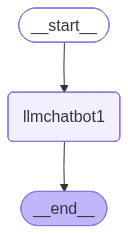

In [8]:
graph

In [9]:
from IPython.display import Image, display

try:
    display(Image(graph_builder.get_graph().draw_mermaid_png()))
except Exception :
    pass

In [11]:
response = graph.invoke({"messages": [llm.invoke("Hello, how are you?")]})

response["messages"][-1].content

"<think>\nOkay, the user just sent another empty message. Let me check the history. The previous interaction was the user sending an empty message, and I responded with a friendly greeting, asking how they're doing. Now they're replying with another empty message.\n\nHmm, maybe they're testing the system or just not sure how to start. Since the user didn't provide any context or question, I need to keep the response open-ended and encouraging. I should avoid assuming their intent but make sure they feel comfortable to ask anything.\n\nIn the previous response, I used emojis to make it friendly. Maybe they're more comfortable with a casual tone. I should keep that approach. Also, considering they might be looking for a specific type of interaction, I can offer examples of what they can ask for, like advice, information, or just someone to talk to. That way, I'm guiding them without being pushy.\n\nI need to make sure the response is welcoming and not too verbose. Let me keep it simple a

In [12]:
for event in graph.stream({"messages": "Hi, How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user just said, "Hi, How are you?" I need to respond appropriately. First, I should acknowledge their greeting. Since they're asking about my well-being, I should mention that I'm functioning well. But I need to remember I'm an AI and can't have real feelings. I should keep the response friendly and open-ended. Maybe add an emoji to keep it light. Also, ask them how they're doing to keep the conversation going. Let me check if there's anything else. No, that's the main points. Let me put it all together concisely.
</think>

Hello! I'm doing well, thank you! 😊 How can I assist you today?


In [2]:
#LangGraph with tools 
from langchain_tavily import TavilySearchResults

ModuleNotFoundError: No module named 'langchain_tavily'